# 03 — Sentiment Scoring with VADER

**Goal:** Apply VADER NLP sentiment scoring to the review text, compare VADER scores to pre-labelled sentiment, and store results back to disk and SQLite.

**Input:** `data/processed/cleaned_sentiment.csv`  
**Output:** `data/processed/sentiment_scored.csv` + SQLite database

In [2]:
import pandas as pd
import sqlite3
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

df = pd.read_csv('../data/processed/cleaned_sentiment.csv')
print(f'Loaded: {df.shape}')

Loaded: (25000, 18)


## 1. Apply VADER scoring

In [3]:
analyzer = SentimentIntensityAnalyzer()

def get_vader_scores(text):
    """Return VADER compound, positive, negative, neutral scores."""
    scores = analyzer.polarity_scores(str(text))
    return scores['compound'], scores['pos'], scores['neg'], scores['neu']

print('Running VADER on 25,000 reviews...')
df[['vader_compound', 'vader_pos', 'vader_neg', 'vader_neu']] = (
    df['review_text_clean'].apply(get_vader_scores).apply(pd.Series)
)

# Map compound score to sentiment label
def vader_label(compound):
    if compound >= 0.05:
        return 'positive'
    elif compound <= -0.05:
        return 'negative'
    else:
        return 'neutral'

df['vader_sentiment'] = df['vader_compound'].apply(vader_label)

print('Done.')
df[['review_text', 'sentiment', 'vader_compound', 'vader_sentiment']].head(8)

Running VADER on 25,000 reviews...
Done.


,review_text,sentiment,vader_compound,vader_sentiment
0,very disappointed with the quality.,negative,-0.5256,negative
1,fast delivery and great packaging.,positive,0.6249,positive
2,very disappointed with the quality.,negative,-0.5256,negative
3,product stopped working after few days.,negative,-0.2263,negative
4,neutral about the quality.,neutral,0.0000,neutral
5,"amazing experience, highly recommend!",positive,0.7645,positive
6,great value for money.,positive,0.7579,positive
7,excellent product! exceeded expectations.,positive,0.5719,positive


## 2. Compare VADER vs pre-labelled sentiment

VADER vs pre-labelled agreement: 19911/25000 = 79.6%


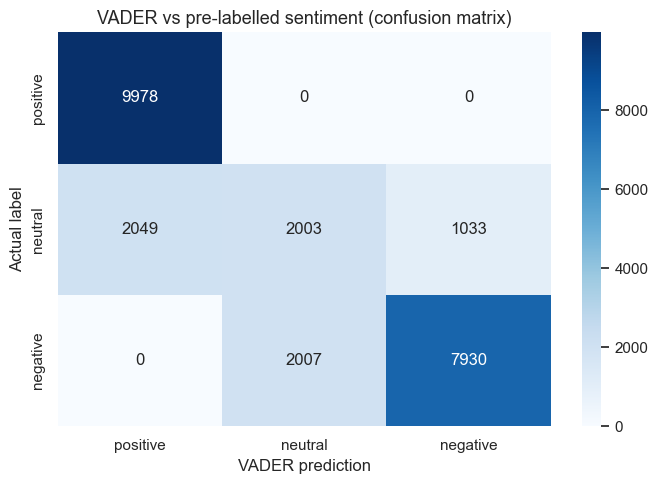

              precision    recall  f1-score   support

    positive       0.83      1.00      0.91      9978
     neutral       0.50      0.39      0.44      5085
    negative       0.88      0.80      0.84      9937

    accuracy                           0.80     25000
   macro avg       0.74      0.73      0.73     25000
weighted avg       0.78      0.80      0.79     25000



In [5]:
# Accuracy check
match = (df['sentiment'] == df['vader_sentiment']).sum()
total = len(df)
print(f'VADER vs pre-labelled agreement: {match}/{total} = {match/total*100:.1f}%')

# Confusion matrix
from sklearn.metrics import confusion_matrix, classification_report
labels = ['positive', 'neutral', 'negative']
cm = confusion_matrix(df['sentiment'], df['vader_sentiment'], labels=labels)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=labels, yticklabels=labels, ax=ax)
ax.set_title('VADER vs pre-labelled sentiment (confusion matrix)', fontsize=13)
ax.set_xlabel('VADER prediction')
ax.set_ylabel('Actual label')
plt.tight_layout()
plt.savefig('../assets/06_vader_confusion.png', bbox_inches='tight')
plt.show()

print(classification_report(df['sentiment'], df['vader_sentiment'], labels=labels))

## 3. VADER compound score distribution

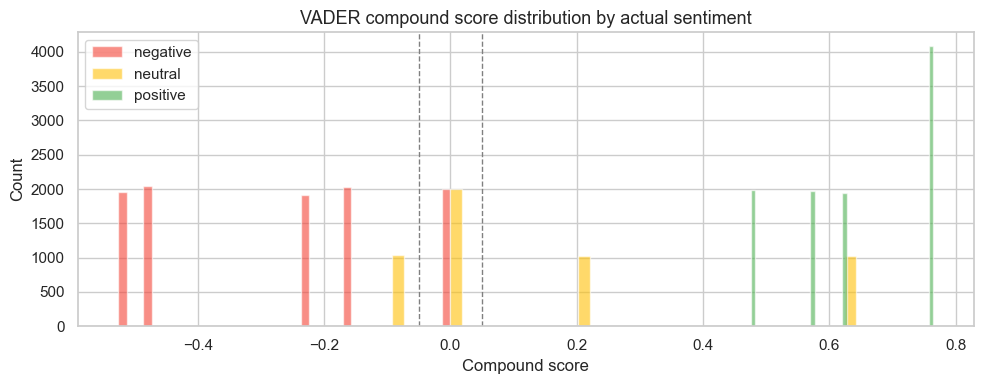

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
colors = {'positive': '#4CAF50', 'neutral': '#FFC107', 'negative': '#F44336'}
for label, grp in df.groupby('sentiment'):
    grp['vader_compound'].hist(bins=40, alpha=0.6, label=label,
        color=colors[label], ax=ax)
ax.axvline(0.05, color='gray', linestyle='--', linewidth=1)
ax.axvline(-0.05, color='gray', linestyle='--', linewidth=1)
ax.set_title('VADER compound score distribution by actual sentiment', fontsize=13)
ax.set_xlabel('Compound score')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig('../assets/07_vader_distribution.png', bbox_inches='tight')
plt.show()

## 4. Save scored data to CSV and SQLite

In [7]:
# Save to CSV
df.to_csv('../data/processed/sentiment_scored.csv', index=False)
print('Saved sentiment_scored.csv')

# Save to SQLite
conn = sqlite3.connect('../data/sentiment_db.sqlite')
df.to_sql('reviews', conn, if_exists='replace', index=False)
print(f'Written to SQLite: {conn.execute("SELECT COUNT(*) FROM reviews").fetchone()[0]} rows')
conn.close()

Saved sentiment_scored.csv
Written to SQLite: 25000 rows
